## DATA 620 Project 2
Denise Atherley

## Introduction & Setup
For Project 2 we are asked to identify a large 2-node network dataset that consists of ties between and not within two (or more) distinct groups. To accomplish this, I identified a publicly available data set on The Department of Labor O*NET Resource Center Database. It contains tables on different occupations and the skills needed for the role. It is a highly dense network that requires thresholding to make sense of because almost every single occupation requires universal baseline skills like "Active Listening," "Critical Thinking," or "Reading Comprehension." The two nodes are the Occupations and the Skills and the edges are the ties that exist strictly between an Occupation and a Skill, weighted by how important that skill is to that specific job, or the "Data Value". There are no ties connecting an Occupation directly to another Occupation, or a Skill directly to another Skill within the raw data.

To maintain a clean analytics architecture, I've divided the solution into two distinct processes: the database build phase, which is where I'll clean and merge the raw data that I've included in my GitHub environment, and the analysis phase, which is where I'll project the network and apply the Island Method.

In [25]:
import pandas as pd

# Ingest the raw data directly from the GitHub repository
skills_url = 'https://raw.githubusercontent.com/DRA-SPS27/DATA-620---Week-3/refs/heads/main/Skills.csv'
occ_url = 'https://raw.githubusercontent.com/DRA-SPS27/DATA-620---Week-3/refs/heads/main/Occupations.csv'

skills_df = pd.read_csv(skills_url)
occ_df = pd.read_csv(occ_url)

# Filter for the Importance ('IM') scale to prevent duplicate edges
clean_skills = skills_df[skills_df['Scale ID'] == 'IM'].copy()

# Filter out explicitly non-relevant ties (keeping 'N' or missing values)
if 'Not Relevant' in clean_skills.columns:
    clean_skills = clean_skills[(clean_skills['Not Relevant'] == 'N') | (clean_skills['Not Relevant'].isna())]

# Merge with the Occupations dataframe to get clean titles for the source nodes
clean_skills = clean_skills.merge(occ_df[['O*NET-SOC Code', 'Title']], on='O*NET-SOC Code', how='left')

# Select relevant columns for the final edge-list
# Source = Occupation Title, Target = Skill Name, Weight = Data Value (Importance Score)
clean_edgelist = clean_skills[['Title', 'Element Name', 'Data Value']].copy()
clean_edgelist.columns = ['occupation', 'skill', 'weight']

# Ensure weights are numeric and drop missing values
clean_edgelist['weight'] = pd.to_numeric(clean_edgelist['weight'], errors='coerce')
clean_edgelist = clean_edgelist.dropna(subset=['weight'])

# Export the clean build
# Saving to a dedicated file isolates the data preparation from the analytical phase
clean_edgelist.to_csv('clean_onet_edgelist.csv', index=False)
print("Database build complete. Cleaned edge-list saved to 'clean_onet_edgelist.csv'.")

Database build complete. Cleaned edge-list saved to 'clean_onet_edgelist.csv'.


## Network Analysis
### Bipartite Projection

With the clean edge-list generated, the next step is to perform the network math using NetworkX.

Because a bipartite graph consists solely of ties between the two groups, you cannot easily threshold it directly. First, the bipartite graph is projected into two separate unipartite graphs: an Occupation-to-Occupation network and a Skill-to-Skill network. Once projected, the Island Method is applied by raising the "water level" (setting a weight threshold) to drop weak ties and shatter the giant, highly dense component into isolated islands.

In [26]:
import pandas as pd
import networkx as nx
from networkx.algorithms import bipartite

# Load the clean edge-list
df = pd.read_csv('clean_onet_edgelist.csv')

# Initialize the bipartite graph efficiently
B = nx.from_pandas_edgelist(
    df, 
    source='occupation', 
    target='skill', 
    edge_attr='weight'
)

# Extract unique nodes for each partition
occupations = df['occupation'].unique().tolist()
skills = df['skill'].unique().tolist()

# Define bipartite attributes for nodes (0 for occupations, 1 for skills)
nx.set_node_attributes(B, {occ: 0 for occ in occupations}, 'bipartite')
nx.set_node_attributes(B, {skill: 1 for skill in skills}, 'bipartite')

assert bipartite.is_bipartite(B), "Error: The graph is not perfectly bipartite."

# Define the custom weight function here
def custom_weight(G, u, v, weight='weight'):
    w = 0
    # For every shared neighbor between node u and node v
    for nbr in set(G[u]) & set(G[v]):
        # Add the original weights from the DataFrame together
        w += G[u][nbr].get(weight, 1) + G[v][nbr].get(weight, 1)
    return w

# 3. Bipartite Projection (Updated to use the custom function)
print("Projecting bipartite graph into unipartite networks using custom weights...")

# Project occupations using the custom weights
occ_network = bipartite.generic_weighted_projected_graph(
    B, 
    occupations, 
    weight_function=custom_weight
)

# Project skills using the custom weights
skill_network = bipartite.generic_weighted_projected_graph(
    B, 
    skills, 
    weight_function=custom_weight
)

print(f"Occupation network: {occ_network.number_of_nodes()} nodes, {occ_network.number_of_edges()} edges")
print(f"Skill network: {skill_network.number_of_nodes()} nodes, {skill_network.number_of_edges()} edges")

Projecting bipartite graph into unipartite networks using custom weights...
Occupation network: 879 nodes, 385881 edges
Skill network: 35 nodes, 595 edges


## Visualizing Full Projections

Rendering Full Occupation Projection...


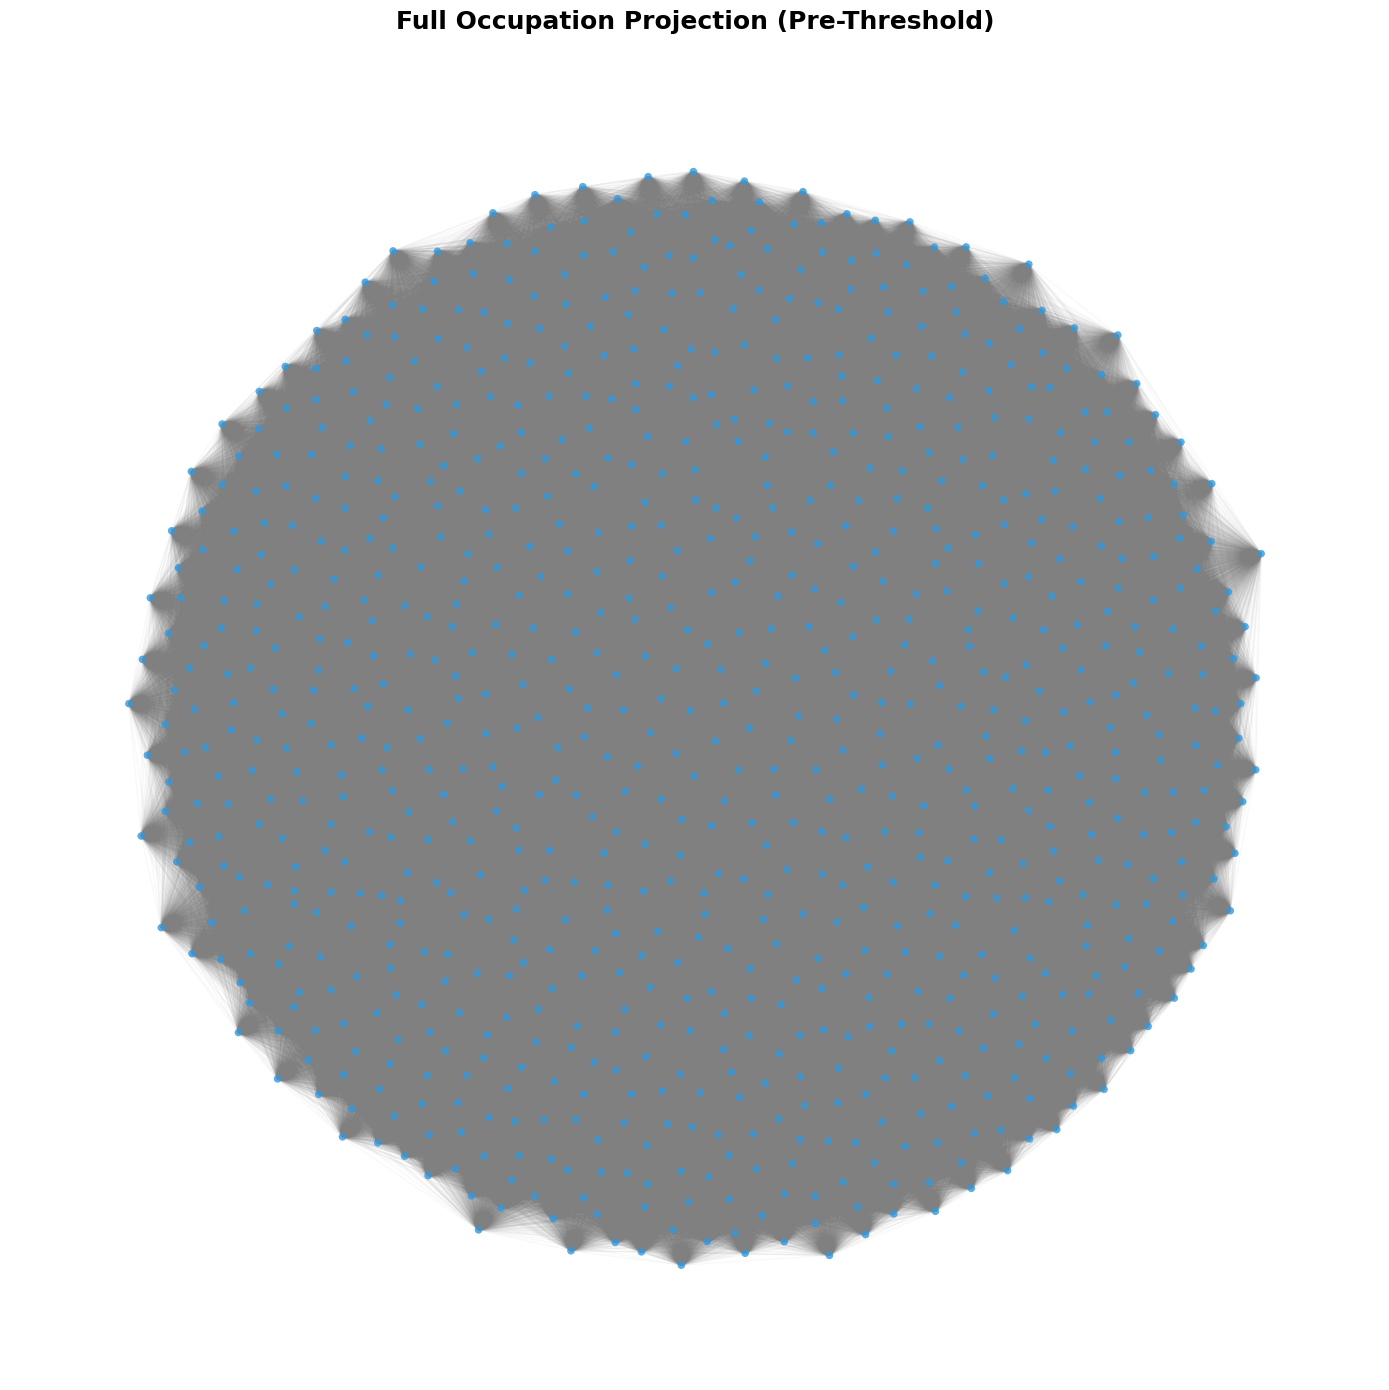

Rendering Full Skill Projection...


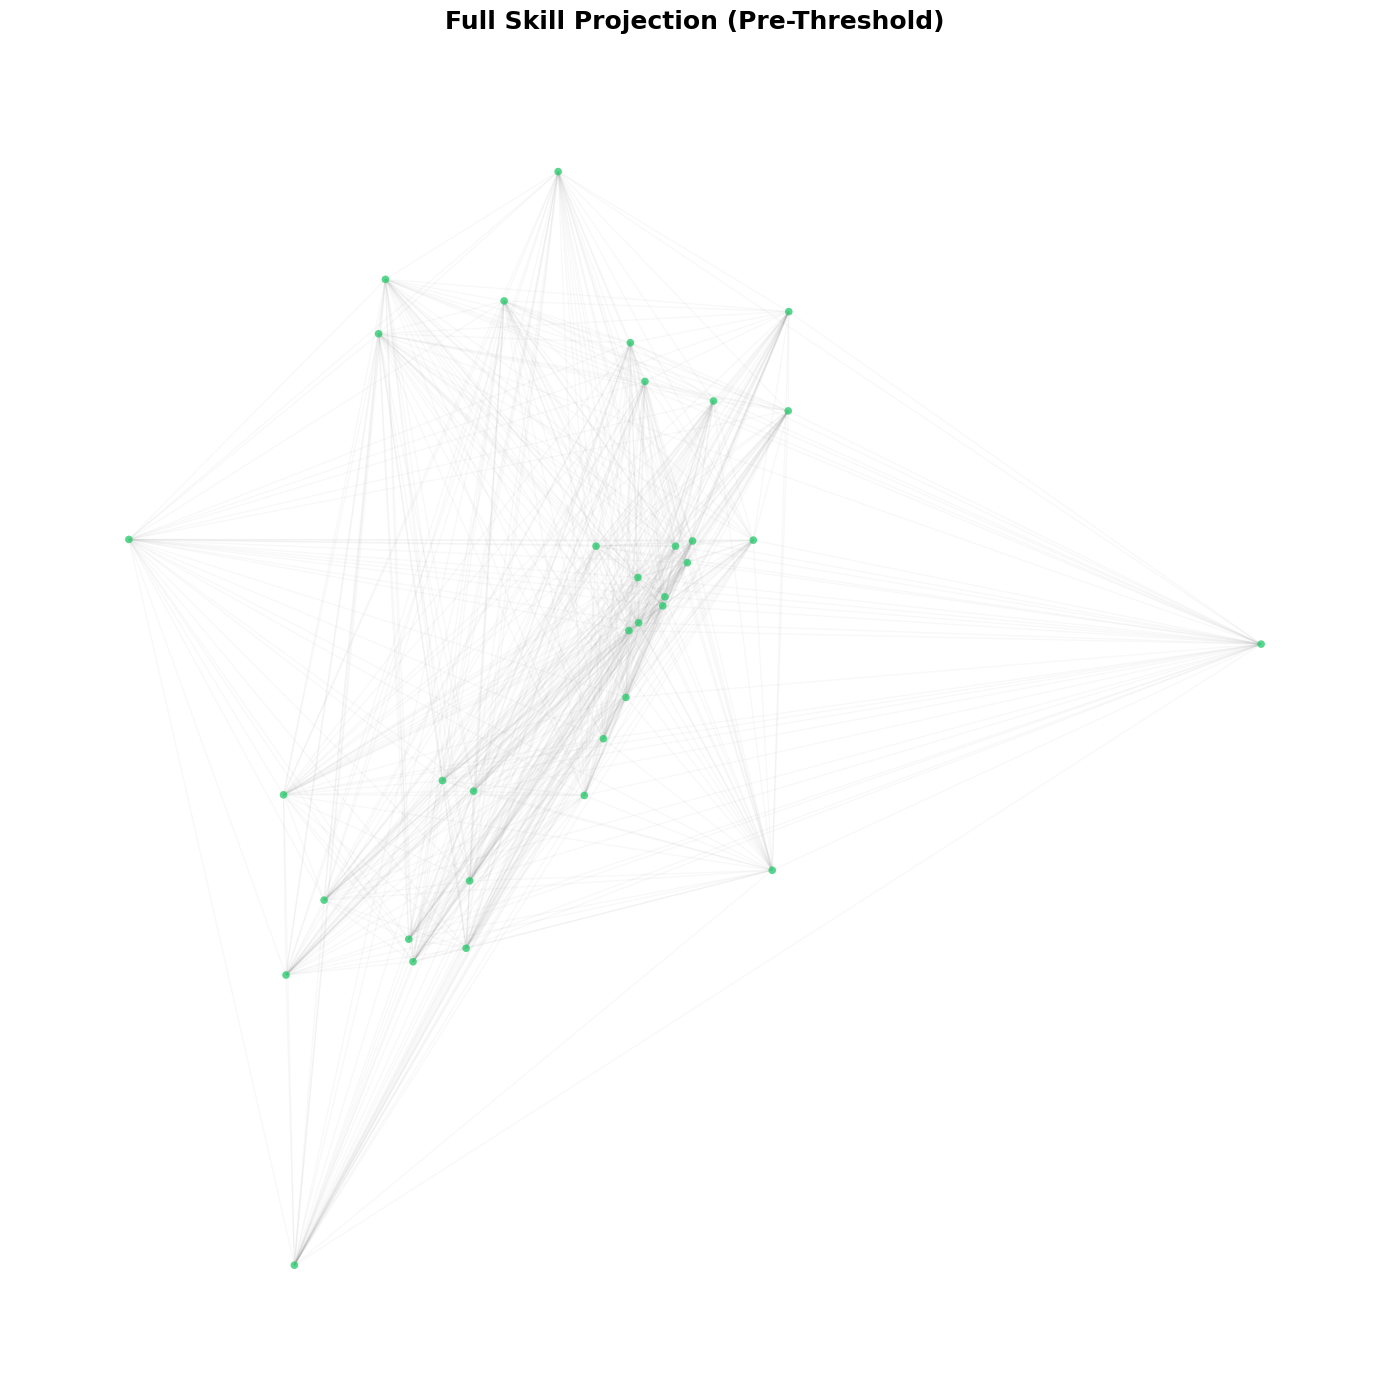

In [27]:
import matplotlib.pyplot as plt
import networkx as nx

# Define a reusable plotting function to handle both dense and sparse graphs
def visualize_network(G, title, node_color, edge_alpha=0.1, with_labels=False):
    """
    Generates a matplotlib visualization of a network graph.
    Adjusts layout parameters to handle high-density networks.
    """
    plt.figure(figsize=(14, 14))
    plt.title(title, fontsize=18, fontweight='bold', pad=20)
    
    # The spring layout simulates anti-gravity between nodes and spring-like edges
    pos = nx.spring_layout(G, k=0.15, seed=42)
    
    # Draw nodes and edges
    nx.draw_networkx_nodes(G, pos, node_size=30, node_color=node_color, alpha=0.8, edgecolors='none')
    nx.draw_networkx_edges(G, pos, alpha=edge_alpha, edge_color='gray')
    
    # Add labels only for the reduced networks (islands) to avoid unreadable text overlapping
    if with_labels and len(G.nodes) < 150:
        nx.draw_networkx_labels(G, pos, font_size=8, font_color='black')
        
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# 1. Visualize the Full Projections (The "Hairballs")
print("Rendering Full Occupation Projection...")
visualize_network(
    occ_network, 
    "Full Occupation Projection (Pre-Threshold)", 
    node_color='#3498db', # Blue
    edge_alpha=0.05,      # Very low alpha due to extreme density
    with_labels=False
)

print("Rendering Full Skill Projection...")
visualize_network(
    skill_network, 
    "Full Skill Projection (Pre-Threshold)", 
    node_color='#2ecc71', # Green
    edge_alpha=0.05,
    with_labels=False
)

## Applying the Island Method & Visualizing the Reduced Networks
The projected graphs are extremely dense (almost fully connected) because most occupations share at least one skill every other occupation. The Island Method reduces the size and complexity of the network by setting a "water level" (a threshold). I drop edges that fall below this threshold, revealing the isolated "islands" of core relationships.

Maximum shared skills between occupations: 231.77999999999997
Maximum shared occupations between skills: 6267.75

Isolated 1 distinct occupation islands at threshold 224.82659999999996.
Isolated 1 distinct skill islands at threshold 5954.362499999999.

Rendering Occupation Islands...


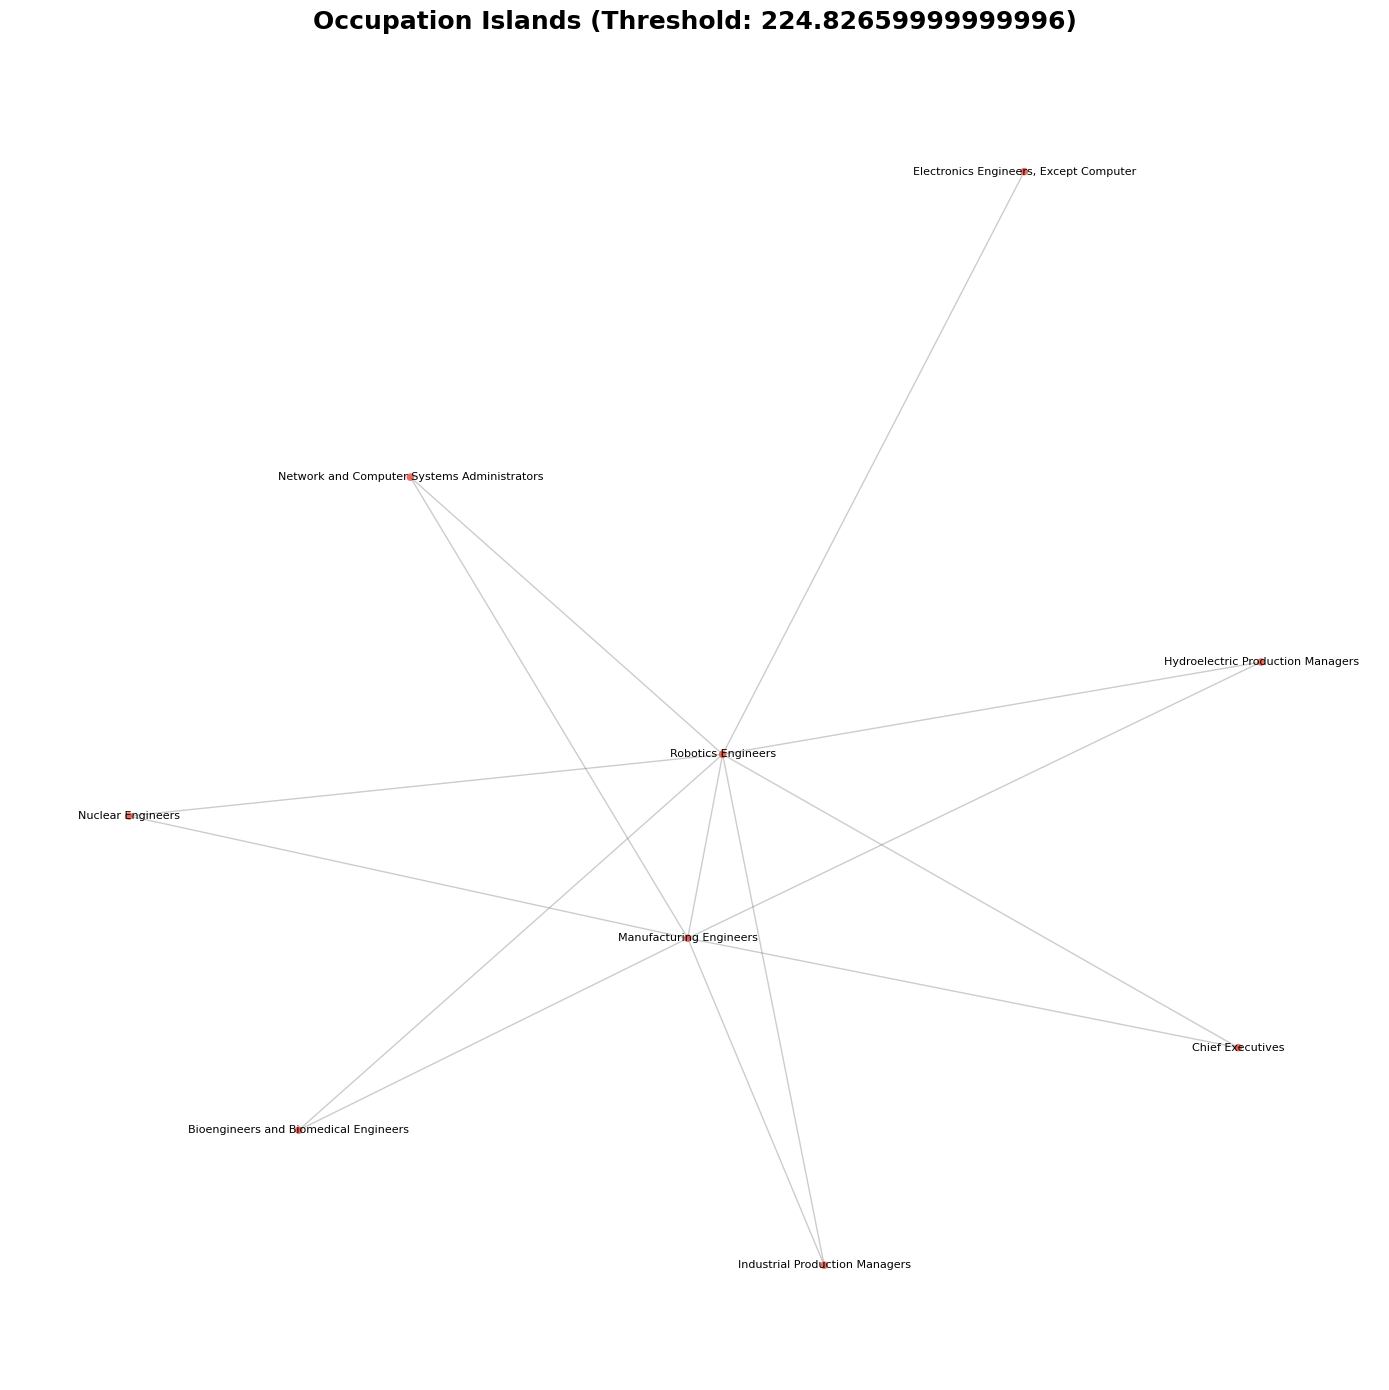


Rendering Skill Islands...


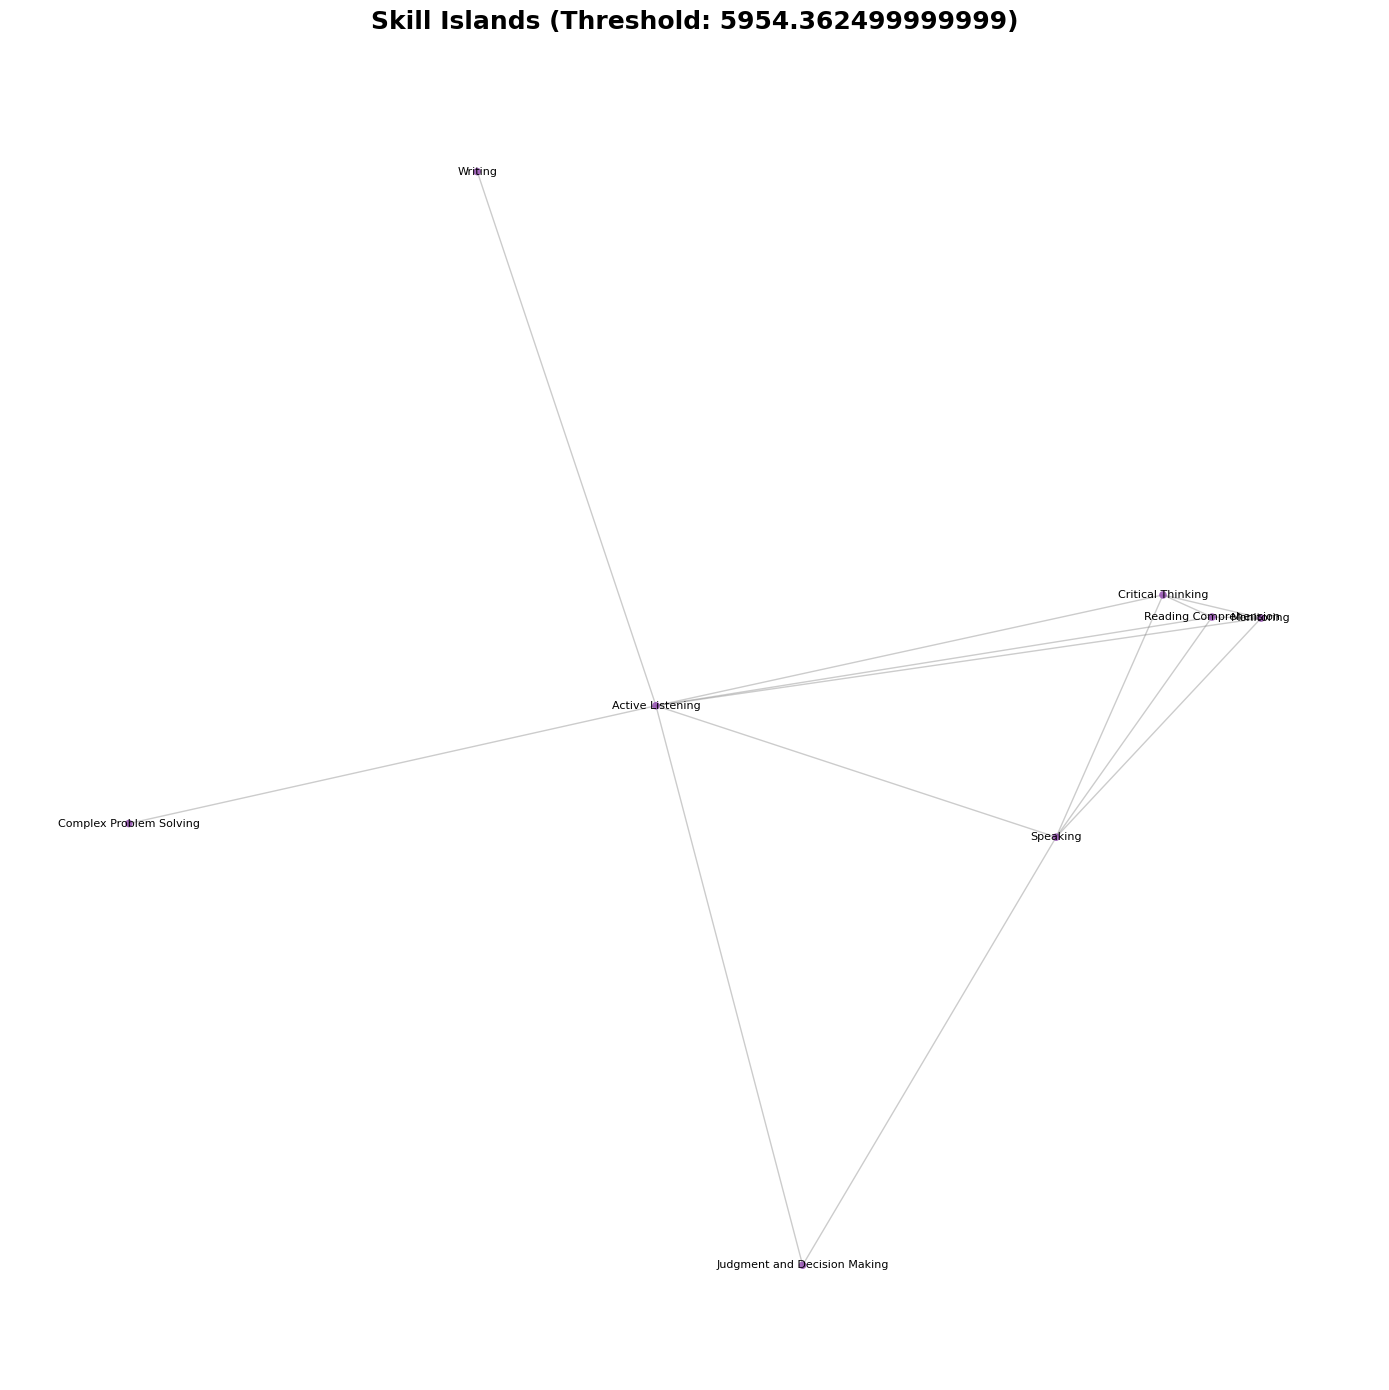

In [28]:
# The Island Method (Thresholding) Logic
def extract_islands(graph, water_level):
    """
    Raises the 'water level' by removing edges below a specific weight threshold.
    Returns a list of disconnected subgraphs (islands) that survive.
    """
    G = graph.copy()
    
    # Identify ties below the threshold safely
    weak_ties = [(u, v) for u, v, d in G.edges(data=True) if d.get('weight', 0) < water_level]
    
    # Remove weak ties to simulate rising water
    G.remove_edges_from(weak_ties)
    
    # Isolate the remaining islands (components with more than 1 node)
    islands = [G.subgraph(c).copy() for c in nx.connected_components(G) if len(c) > 1]
    return islands

# Dynamically determine thresholds safely (using default=0 to avoid empty sequence errors)
max_occ_weight = max([d.get('weight', 0) for u, v, d in occ_network.edges(data=True)], default=0)
max_skill_weight = max([d.get('weight', 0) for u, v, d in skill_network.edges(data=True)], default=0)

print(f"Maximum shared skills between occupations: {max_occ_weight}")
print(f"Maximum shared occupations between skills: {max_skill_weight}")

# Set the water level (The multiplier can be tweaked to refine the islands)
occ_threshold = max_occ_weight * 0.97  
skill_threshold = max_skill_weight * 0.95

# Execute Thresholding
occupation_islands = extract_islands(occ_network, occ_threshold)
skill_islands = extract_islands(skill_network, skill_threshold)

print(f"\nIsolated {len(occupation_islands)} distinct occupation islands at threshold {occ_threshold}.")
print(f"Isolated {len(skill_islands)} distinct skill islands at threshold {skill_threshold}.")

# Visualize the Reduced Networks (The Islands)
if occupation_islands:
    print("\nRendering Occupation Islands...")
    reduced_occ_network = nx.compose_all(occupation_islands)
    visualize_network(
        reduced_occ_network, 
        f"Occupation Islands (Threshold: {occ_threshold})", 
        node_color='#e74c3c', # Red
        edge_alpha=0.4,       
        with_labels=True      
    )
else:
    print("\nNo occupation islands found. Try lowering the occ_threshold multiplier.")

if skill_islands:
    print("\nRendering Skill Islands...")
    reduced_skill_network = nx.compose_all(skill_islands)
    visualize_network(
        reduced_skill_network, 
        f"Skill Islands (Threshold: {skill_threshold})", 
        node_color='#8e44ad', # Purple
        edge_alpha=0.4,
        with_labels=True      
    )
else:
    print("\nNo skill islands found. Try lowering the skill_threshold multiplier.")

## Inferences
By projecting the network and applying the Island Method, I was able to move past the "hairball" of the giant full projections and can make distinct structural inferences about both sides of the labor market.

**Inferences regarding the Occupation Group:**
In the raw network, completely unrelated roles, like a Software Developer and a Dental Hygienist, are weakly connected because they both require universal human skills, such as "Reading Comprehension" or "Active Listening."

When I apply the Island Method threshold to the projected Occupation network, those weak ties vanish and the islands that remain allow me to infer the boundaries of highly specialized career tracks. An occupation only survives on an island with another occupation if they share a massive, highly specific combination of technical competencies. The results show that Robotics Engineers and Manufacturing Engineers serve as central hubs. These two occupations share an overlapping skill set. I can assume that transitioning between being a Robotics Engineer and a Manufacturing Engineer will require minimal retraining and be a smooth transition.

This island does not represent basic technical skills, like coding or using a specific tool. Instead, it represents high-level systems management. The shared skills keeping this island afloat are almost certainly cognitive and operational. 

**Inferences regarding the Skill Group:**
When thresholding the projected Skill network, the surviving islands represent the fundamental "soft-skills" or "baseline cognitive stack" required for almost all professional, managerial and knowledge-economy roles. In the market, employers usually demand these skills as a bundled package.

Active Listening sits at the center of the graph and acts as the primary anchor tethering the other skills together. It's a crucuial bridge between receptive skills, like reading comprehension, and expressive/action-oriented skills, like speaking or critical problem solving. A worker won't effectively deploy complex problem-solving or good judgement without first absorbing inforamtion through active listening. 

Speaking, Critical thinking, Reading Comprehension and Monitoring are tightly clustered together on the right side of the graph meaning they are interconnected with one another, not just with the center. 

Almost every high-level occupation in the database requires these skills. An approach I could take to iterate this work is to filter out these universal and foundational skills from the initial dataset to find the more specialized technical skill bundles.